# 09 - Attrition vs moment

**Input:** `data/processed/strokes_all.csv`, `data/processed/player_clusters_W.csv`, `data/raw/match.csv`
**What it does:** women's singles. Tests whether rallies are won by attrition (the loser is progressively pushed out of position) or by a single moment (level until one decisive shot). Uses the hitter's own distance from court center as the 'in trouble' signal and plots the winner-vs-loser stretch trajectory plus the gap between them.
**Output:** `output/attrition_check.png`, printed table.

Analysis type: descriptive / mechanism test. Verdict prints as one of: attrition, single-moment, or even-execution.

In [1]:
## --- path bootstrap: run from the repo root no matter where this is launched ---
## nbconvert and some editors set the working directory to the notebook's own
## folder. Walk up until we find the repo root (the folder containing data/),
## chdir there so relative data paths resolve, and put code/ on sys.path so the
## shared modules (utils.py, shot_translations.py) import cleanly.
import os, sys
_d = os.getcwd()
for _ in range(5):
    if os.path.isdir(os.path.join(_d, "data")):
        break
    _d = os.path.dirname(_d)
os.chdir(_d)
if os.path.join(_d, "code") not in sys.path:
    sys.path.insert(0, os.path.join(_d, "code"))
print("working directory:", os.getcwd())

working directory: /Users/aakankshvaidya/Desktop/qss20_final_project


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import utils

In [3]:
## CONFIG
PROC_DIR = utils.PROC_DIR
OUT_DIR = utils.OUT_DIR
os.makedirs(OUT_DIR, exist_ok=True)
RESTRICT_TO_WOMENS = True
MIN_SHOTS = 3

## Load, resolve names, restrict to women's

In [4]:
strokes = utils.load_strokes()
matches = utils.load_matches()
strokes = utils.map_player_names(strokes, matches)
if RESTRICT_TO_WOMENS:
    strokes = utils.restrict_to_womens(strokes, how="clusters")
print("strokes:", len(strokes))

map_player_names: rows before merge = 52356, after = 52356
map_player_names: unique players resolved = 35
restrict_to_womens: rows before filter = 52356, after = 22503
strokes: 22503


## Player's own stretch (distance of hitter from court center)

In [5]:
cx = strokes["player_location_x"].median()
cy = strokes["player_location_y"].median()
print(f"estimated court center: ({cx:.0f}, {cy:.0f})")

strokes = strokes.dropna(subset=["player_location_x", "player_location_y", "hitter_won_rally"]).copy()
strokes["own_stretch"] = np.sqrt(
    (strokes["player_location_x"] - cx) ** 2 + (strokes["player_location_y"] - cy) ** 2
)

strokes = strokes.sort_values(["match_id", "set_num", "rally", "player_name", "ball_round"])
grp = strokes.groupby(["match_id", "set_num", "rally", "player_name"])
strokes["shot_idx"] = grp.cumcount()
strokes["shot_total"] = grp["ball_round"].transform("size")
strokes = strokes[strokes["shot_total"] >= MIN_SHOTS].copy()
strokes["rel_pos"] = strokes["shot_idx"] / (strokes["shot_total"] - 1)
strokes["pos_bin"] = (strokes["rel_pos"] * 10).round() / 10

estimated court center: (632, 454)


## Stretch trajectory: winners vs losers, and the gap

In [6]:
traj = strokes.groupby(["pos_bin", "hitter_won_rally"])["own_stretch"].mean().reset_index()
traj_pivot = traj.pivot(index="pos_bin", columns="hitter_won_rally", values="own_stretch")
traj_pivot.columns = ["losers", "winners"]
traj_pivot["gap (loser - winner)"] = traj_pivot["losers"] - traj_pivot["winners"]
print(traj_pivot.round(1))

         losers  winners  gap (loser - winner)
pos_bin                                       
0.0       120.7    117.9                   2.9
0.1       146.9    138.4                   8.5
0.2       148.8    146.6                   2.1
0.3       153.2    145.8                   7.4
0.4       150.3    149.6                   0.7
0.5       153.6    148.5                   5.1
0.6       156.0    150.2                   5.8
0.7       154.5    149.9                   4.6
0.8       152.8    152.9                  -0.0
0.9       162.4    155.3                   7.0
1.0       152.3    152.1                   0.3


## Classify the pattern\nattrition = gap grows toward the end; single-moment = flat then spikes at the final shot; even-execution = small and flat throughout.

In [7]:
early = traj_pivot.loc[traj_pivot.index <= 0.7, "gap (loser - winner)"].mean()
late_mid = traj_pivot.loc[(traj_pivot.index > 0.7) & (traj_pivot.index < 1.0), "gap (loser - winner)"].mean()
final = traj_pivot.loc[traj_pivot.index == 1.0, "gap (loser - winner)"].values[0]
overall_scale = traj_pivot[["losers", "winners"]].mean().mean()

print(f"mean gap, first 70% of rally: {early:+.1f}")
print(f"mean gap, 70-100% (excl final): {late_mid:+.1f}")
print(f"gap on the final shot: {final:+.1f}")
print(f"(typical stretch is ~{overall_scale:.0f} units)")
print(f"the average gap (~{early:.0f}) is about {early/overall_scale*100:.0f}% of typical stretch")

if final > 2 * max(early, 1) and final > 8:
    print("=> SINGLE-MOMENT: gap small through the rally, then spikes at the end.")
elif late_mid > 1.8 * max(early, 1):
    print("=> ATTRITION: gap widens steadily toward the end.")
else:
    print("=> EVEN-EXECUTION: gap small and roughly flat throughout, no terminal spike.")
    print("   Winner and loser are positionally near-identical the whole rally.")

mean gap, first 70% of rally: +4.6
mean gap, 70-100% (excl final): +3.5
gap on the final shot: +0.3
(typical stretch is ~148 units)
the average gap (~5) is about 3% of typical stretch
=> EVEN-EXECUTION: gap small and roughly flat throughout, no terminal spike.
   Winner and loser are positionally near-identical the whole rally.


## Figure

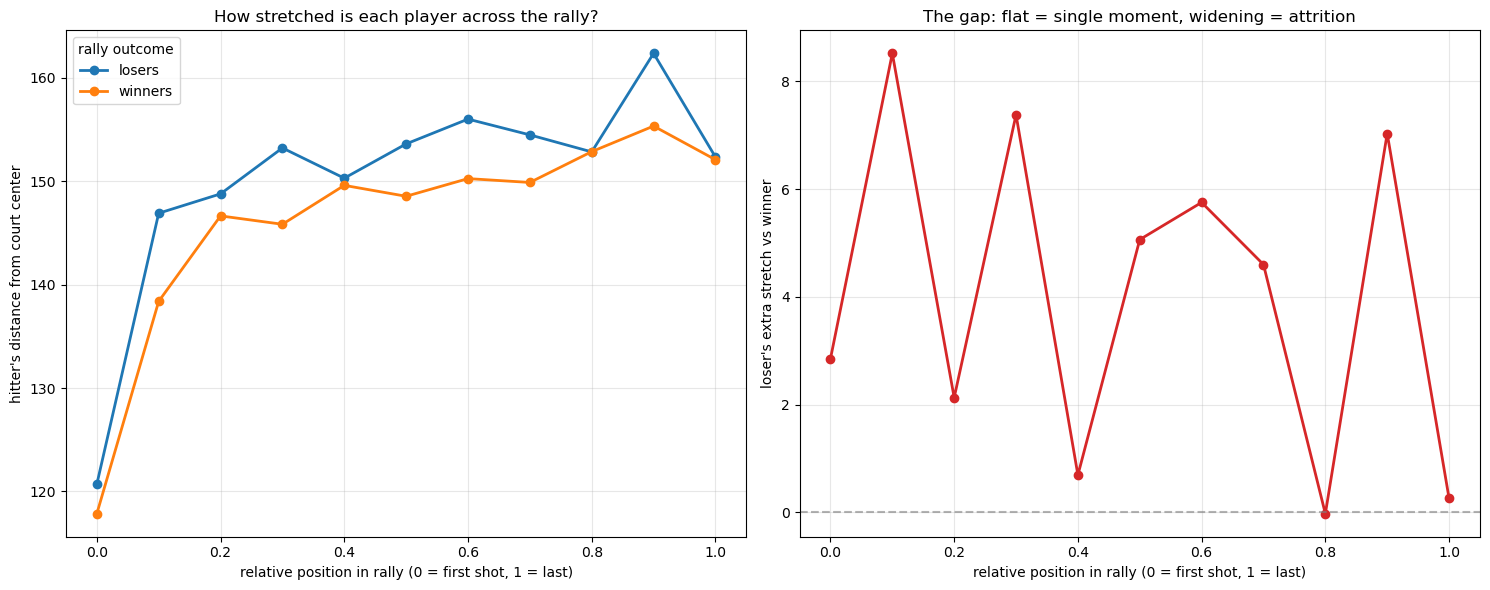

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
traj_pivot[["losers", "winners"]].plot(ax=ax1, marker="o", linewidth=2)
ax1.set_xlabel("relative position in rally (0 = first shot, 1 = last)")
ax1.set_ylabel("hitter's distance from court center")
ax1.set_title("How stretched is each player across the rally?")
ax1.legend(title="rally outcome"); ax1.grid(alpha=0.3)

ax2.plot(traj_pivot.index, traj_pivot["gap (loser - winner)"], marker="o", linewidth=2, color="#d62728")
ax2.axhline(0, color="gray", linestyle="--", alpha=0.6)
ax2.set_xlabel("relative position in rally (0 = first shot, 1 = last)")
ax2.set_ylabel("loser's extra stretch vs winner")
ax2.set_title("The gap: flat = single moment, widening = attrition")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "attrition_check.png"), dpi=150)
plt.show()